In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
# Get all the data
text = open("/content/input.txt").read()
len(text)

1115394

In [ ]:
# Make token for words
itos = {i: s for i, s in enumerate(sorted(list(set(text))))}
stoi = {s: i for i, s in itos.items()}
vocab_size = len(itos)
encode = lambda x: torch.tensor([stoi[ch] for ch in x])
decode = lambda x: "".join([itos[token.item()] for token in x])
# decode(encode("Lochan"))
vocab_size

65

In [ ]:
# Get x and y
context_size = 8
batch_size = 4
def get_batch():
  batches = torch.randint(len(text)-context_size, (batch_size, ))
  x = torch.stack([encode(text[batch:batch+context_size]) for batch in batches])
  y = torch.stack([encode(text[batch+1:batch+context_size+1]) for batch in batches])
  return x, y
x, y = get_batch()

In [ ]:
# make bigram model
torch.manual_seed(1337)

class BiagramModel(nn.Module):
  def __init__(self, vocab_size):
    super().__init__()
    self.token_embedding = nn.Embedding(vocab_size, vocab_size) # 65, 65

  def forward(self, idx, target=None):
    logits = self.token_embedding(idx) # idx - 4, 8 so logits - 4, 8, 65 (B, T, C)
    if target is None:
      loss = None
    else:
      B,T,C = logits.shape
      logits = logits.view(B*T, C)
      target = target.view(B*T)
      loss = F.cross_entropy(logits, target)
    return logits, loss

  def generate(self, idx, max_new_tokens):
    # in first logits are in (B, T, C) and idx is B, T
    for i in range(max_new_tokens):
      logits, loss = self(idx)
      logits = logits[:, -1, :] #(B, C)
      probs = F.softmax(logits, dim=1) # (B, C)
      new_idx = torch.multinomial(probs, num_samples=1) # (B, 1)
      idx = torch.cat([idx, new_idx], dim=1) # (B, T+1)
    return idx
m = BiagramModel(vocab_size)
logits, loss = m(x, y)
# print(logits.shape)
# print(loss)

# generate
decode(m.generate(torch.ones(1, 1, dtype=torch.long), 500)[0])

" -KIcLT;AcELMoTbvZv C?nq-QE33:CJqkOKH-q;:la!oiywkHjgChzbQ?u!3bLIgwevmyFJGUGp\nwnYWmnxKWWev-tDqXErVKLgJt-wBpm&yiltNCjeO3:Cx&vvMYW-txjuAd IRFbTpJ$zkZelxZtTlHNzdXXUiQQY:qFINTOBNLI,&oTigq z.c:Cq,SDXzetn3XVjX-YBcHAUhk&PHdhcOb\nnhJ?FJU?pRiOLQeUN!BxjPLiq-GJdUV'hsnla!murI!IM?SPNPq?VgC'R\npD3cLv-bxn-tL!upg\nSZ!Uvdg CtxtT?hsiW:XxKIiPlagHIsr'zKSVxza?GlDWObPmRJgrIAcmspmZ&viCKot:u3qYXA:rZgv f:3Q-oiwUzqh'Z!I'zRS3SP rVchSFUIdd q?sPJpUdhMCK$VXXevXJFMl,i\nYxA:gWId,EXR,iMC,$?srV$VztRwb?KpgUWFjR$zChOLm;JrDnDph\nLBj,KZxJa"

In [ ]:
# Optimizer
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

In [ ]:
lossi = []

In [ ]:
# Let's train Neural Network
for i in range(10000):
  ix, iy =get_batch()
  logits, loss = m(ix, iy)
  optimizer.zero_grad(set_to_none=True)
  loss.backward()

  optimizer.step()
  lossi.append(loss.item())
  if i%500 == 0:
    print(loss.item())

2.7973954677581787
2.148163080215454
2.3145649433135986
2.2897660732269287
2.390340805053711
2.340585708618164
2.578301429748535
2.183579206466675
2.3664069175720215
2.5533447265625
2.3410422801971436
2.321443796157837
2.4387636184692383
2.4215376377105713
2.681999921798706
2.214031457901001
2.727059841156006
2.1444249153137207
2.421909809112549
2.456084728240967


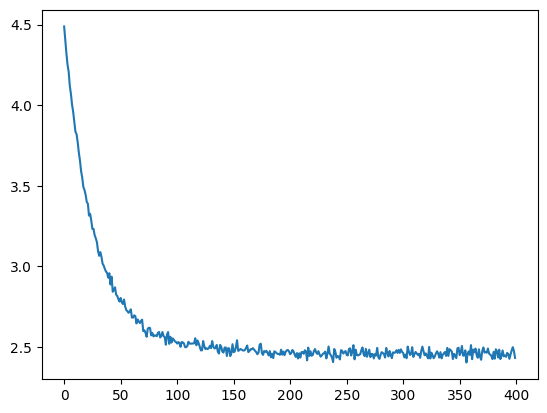

In [ ]:
import matplotlib.pyplot as plt
plt.plot(torch.tensor(lossi).view(-1, 100).mean(dim=1))

In [ ]:
print(decode(m.generate(torch.ones(1, 1, dtype=torch.long), 500)[0]))

 I ed she her tik t chbem r mbu mof
Manld himaisspld onchy, pa tlatit sere nd Yord shemarelde llor vere hall f herithag wayo-l k-sagssho--d yan
The scl.
TREL:
D:
TI'rak t, ortheancukso;

y

Whir, llpinous be mor h bo honts in alun hay h th be isty wanothe;
CETHe hiownour wo thacrd, m: cot e henrt t
Ty
nch y nar-bemer!
Soouronind; sorg thiere chou,
Th l.
Anc,
Ithowo tha s tiemensh, oisthin
venerchy;

TI'lll the
Th, RLLETY:
THe mencalay blt be; menthais stonou, w
CHO: RY: owhavemenchirint woune gh,
